## Classification using the hyper plane

In the 2D example we just evaluated the hyperplane and if the result is greater 0 it belongs to 1 side of the hyper plane and if 0 it belongs to the other side of the hyper plane. In this example we know and fixed the separating hyper plane and by design we get optimal separability as the data is on a regular grid and the classification was based on the linear classification boundry we just used to label the data.

In more general the separating hyperplane assumes a linear separation between the two classes therefor a separating hyperplane has with data X of shape n x p the property of 

$$
y_i (\beta_0 + \beta_1 X_1 + beta_2 X_2 + ... + \beta_p X_p ) > 0 for all i=1...n .
$$

If a separating hyperplane exists we can evaluate new $X_i$ by using the hyperplane equation and check the sign to assign a class label. Furthermore we can use the magnitude to see how far a sample is away from the plane in the p-1 dimensional space. 

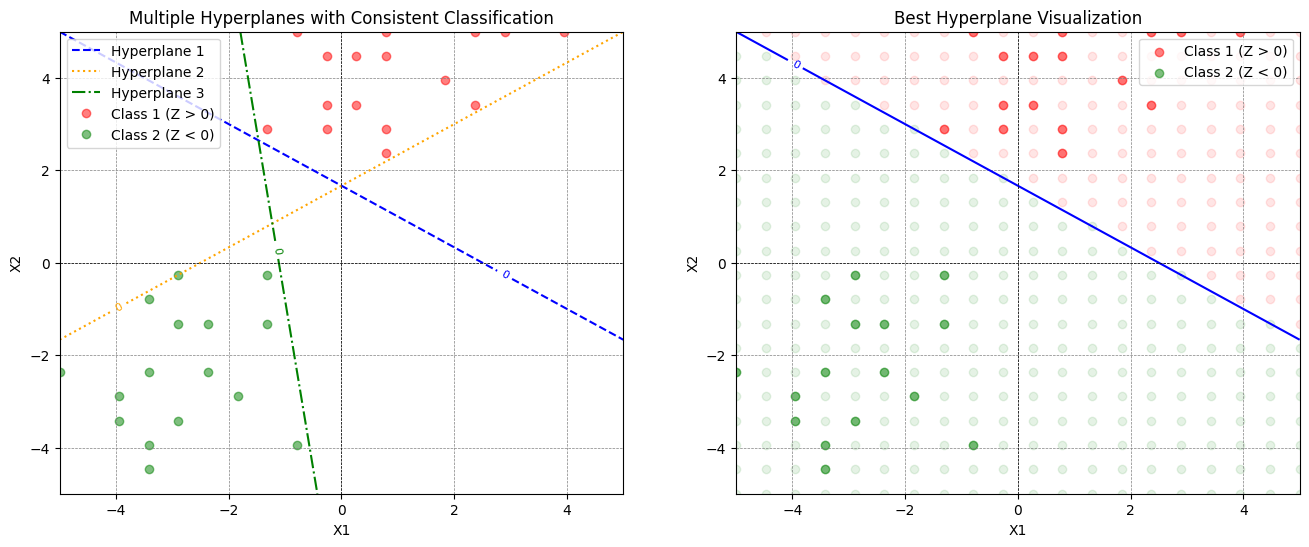

In [117]:
## Example with different hyperplane parameters fulfilling the same classification
import numpy as np
import matplotlib.pyplot as plt
# generate a grid of points in 2D space
x1 = np.linspace(-5, 5, 20)
x2 = np.linspace(-5, 5, 20)
X1, X2 = np.meshgrid(x1, x2)
points = np.c_[X1.ravel(), X2.ravel()]

# define a different hyperplane (line) in 2D space
# e.g. 0.8*x1 + 1.2*x2 - 2 = 0
def hyperplane1(x):
    return 0.8 * x[:, 0] + 1.2 * x[:, 1] - 2

def hyperplane2(x):
    return -0.2 * x[:, 0] + 0.3 * x[:, 1] - 0.5

def hyperplane3(x):
    return 0.9 * x[:, 0] + 0.123 * x[:, 1]  +1


# now find a subset of example points that are classified the same by all three hyperplanes
Z1 = hyperplane1(points).reshape(X1.shape)
Z2 = hyperplane2(points).reshape(X1.shape)
Z3 = hyperplane3(points).reshape(X1.shape)
mask = (Z1.ravel() > 0) & (Z2.ravel() > 0) & (Z3.ravel() > 0)
points_class1 = points[mask]
mask = (Z1.ravel() < 0) & (Z2.ravel() < 0) & (Z3.ravel() < 0)
points_class2 = points[mask]

# select a subset of points which are classified the same by all three hyperplanes
# 1.1 get the number of points in each class
num_class1 = points_class1.shape[0]
num_class2 = points_class2.shape[0]

# 1.2 determine the smaller class size
min_class_size = int(np.ceil(min(num_class1, num_class2) * 0.3)) # use 10% of the smaller class size for visualization

# 1.3 randomly select points from each class for visualization
np.random.seed(42)  # for reproducibility
selected_class1 = points_class1[np.random.choice(num_class1, min_class_size, replace=False)]
selected_class2 = points_class2[np.random.choice(num_class2, min_class_size, replace=False)]

# plot the hyperplanes and the selected points
# make 2 subplots left selecte " training points" with the hyperplanes, right the best hyperplane for the grid points (it is number 1 in this example)
plt.figure(figsize=(16, 6))
# left subplot
plt.subplot(1, 2, 1)
contour1 = plt.contour(X1, X2, hyperplane1(points).reshape(X1.shape), levels=[0], colors='blue', linestyles='dashed')
contour2 = plt.contour(X1, X2, hyperplane2(points).reshape(X1.shape), levels=[0], colors='orange', linestyles='dotted')
contour3 = plt.contour(X1, X2, hyperplane3(points).reshape(X1.shape), levels=[0], colors='green', linestyles='dashdot')
plt.clabel(contour1, inline=True, fontsize=8)   
plt.clabel(contour2, inline=True, fontsize=8)   
plt.clabel(contour3, inline=True, fontsize=8)
plt.scatter(selected_class1[:, 0], selected_class1[:, 1], color='red', alpha=0.5, label='Class 1 (Z > 0)')
plt.scatter(selected_class2[:, 0], selected_class2[:, 1], color='green', alpha=0.5, label='Class 2 (Z < 0)')
plt.title('Multiple Hyperplanes with Consistent Classification')
plt.xlabel('X1')
plt.ylabel('X2')
plt.axhline(0, color='black',linewidth=0.5, ls='--')
plt.axvline(0, color='black',linewidth=0.5, ls='--')
plt.grid(color = 'gray', linestyle = '--', linewidth = 0.5)
# add legend for hyperplanes
blue_line = plt.Line2D([], [], color='blue', linestyle='dashed', label='Hyperplane 1')
orange_line = plt.Line2D([], [], color='orange', linestyle='dotted', label='Hyperplane 2')
green_line = plt.Line2D([], [], color='green', linestyle='dashdot', label='Hyperplane 3')
green_dots = plt.Line2D([], [], color='green', linestyle='None', marker='o', alpha=0.5, label='Class 2 (Z < 0)')
red_dots = plt.Line2D([], [], color='red', linestyle='None', marker='o', alpha=0.5, label='Class 1 (Z > 0)')
plt.legend(handles=[blue_line, orange_line, green_line, red_dots, green_dots])
# right subplot
plt.subplot(1, 2, 2)
contour_best = plt.contour(X1, X2, hyperplane1(points).reshape(X1.shape), levels=[0], colors='blue')
plt.clabel(contour_best, inline=True, fontsize=8)
plt.scatter(selected_class1[:, 0], selected_class1[:, 1], color='red', alpha=0.5, label='Class 1 (Z > 0)')
plt.scatter(selected_class2[:, 0], selected_class2[:, 1], color='green', alpha=0.5, label='Class 2 (Z < 0)')
# also show the full grid of points classified by the best hyperplane
all_points_class1 = points[hyperplane1(points) > 0]
all_points_class2 = points[hyperplane1(points) < 0]
plt.scatter(all_points_class1[:, 0], all_points_class1[:, 1], color='red', alpha=0.1)
plt.scatter(all_points_class2[:, 0], all_points_class2[:, 1], color='green', alpha=0.1)
plt.title('Best Hyperplane Visualization')
plt.xlabel('X1')
plt.ylabel('X2')
plt.axhline(0, color='black',linewidth=0.5, ls='--')
plt.axvline(0, color='black',linewidth=0.5, ls='--')
plt.grid(color = 'gray', linestyle = '--', linewidth = 0.5)
plt.legend()
plt.show()


## The maxial margin classifier

The above example showed that there are many lines (hyperplanes) which lead to a perfect linear separation between the two classes but there is only one solution which separate the two classes best and thus is more robust or generalizes better compared to all other investigated classifiers. If the dataset is separable there exists a infinite number of linear combinations of the beta terms which lead to a perfect linear classification. The goal is now to find out of this infinite amount of solutions the best, which generalizes the best. 

A natural choice is to choose the maximal margin hyperplane which is the best separating hyperplane that is farthest away from the training samples. In order to find this plane we can calculate the perpendicular distance from each point to a hyperplane. The smallest distance to the hyperplane is the the margin. The goal is to maximize this margin and thus find the hyperplane which is farthest away from the margin. We can then classify again new observations $X$ based on which side of the maximum margin hyperplane the point lies as before.

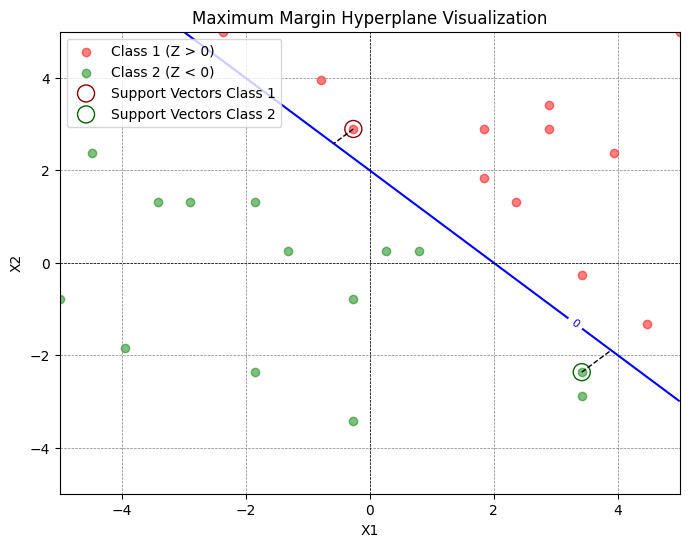

In [118]:
## Example with the maximum margin hyperplane
# generate a grid of points in 2D space as before
x1 = np.linspace(-5, 5, 20)
x2 = np.linspace(-5, 5, 20)
X1, X2 = np.meshgrid(x1, x2)
points = np.c_[X1.ravel(), X2.ravel()]
# define the maximum margin hyperplane (line) in 2D space
def max_margin_hyperplane(x):
    return 0.5 * x[:, 0] + 0.5 * x[:, 1] - 1


# evaluate the maximum margin hyperplane function on the grid points
Z_max_margin = max_margin_hyperplane(points).reshape(X1.shape)
# classify points based on the maximum margin hyperplane
points_class1_mm = points[Z_max_margin.ravel() > 0]
points_class2_mm = points[Z_max_margin.ravel() < 0]

# randomly select a subset of points from each class for visualization
np.random.seed(31)  # for reproducibility
num_class1_mm = points_class1_mm.shape[0]
num_class2_mm = points_class2_mm.shape[0]
# remove points to keep visualization clear also remove points with distance < margin
margin = 0.2
def distance_to_hyperplane(x):
    return np.abs(max_margin_hyperplane(x)) / np.sqrt(0.5**2 + 0.5**2)


min_class_size_mm = int(np.ceil(min(num_class1_mm, num_class2_mm) * 0.1)) # use 10% of the smaller class size for visualization
selected_class1_mm = points_class1_mm[np.random.choice(num_class1_mm, min_class_size_mm, replace=False)]
selected_class2_mm = points_class2_mm[np.random.choice(num_class2_mm, min_class_size_mm, replace=False)]

# remove points that are too close to the hyperplane
selected_class1_mm = selected_class1_mm[distance_to_hyperplane(selected_class1_mm) >= margin]
# remove points that are too close to the hyperplane
selected_class2_mm = selected_class2_mm[distance_to_hyperplane(selected_class2_mm) >= margin]

# find the closest points to the hyperplane from the randomly selected points to illustrate support vectors
distances_class1 = distance_to_hyperplane(selected_class1_mm)
distances_class2 = distance_to_hyperplane(selected_class2_mm)
# select all the support vectors (closest points) from each class

support_vector1 = selected_class1_mm[np.argmin(distances_class1)]
support_vector2 = selected_class2_mm[np.argmin(distances_class2)]
support_vectors = np.array([support_vector1, support_vector2])
# plot the maximum margin hyperplane
plt.figure(figsize=(8, 6))
contour_mm = plt.contour(X1, X2, Z_max_margin, levels=[0], colors='blue')
plt.clabel(contour_mm, inline=True, fontsize=8)
plt.scatter(selected_class1_mm[:, 0], selected_class1_mm[:, 1], color='red', alpha=0.5, label='Class 1 (Z > 0)')
plt.scatter(selected_class2_mm[:, 0], selected_class2_mm[:, 1], color='green', alpha=0.5, label='Class 2 (Z < 0)')
# highlight support vectors by outer circle in dark red or dark green
plt.scatter(support_vector1[0], support_vector1[1], facecolors='none', edgecolors='darkred', s=150, label='Support Vectors Class 1')
plt.scatter(support_vector2[0], support_vector2[1], facecolors='none', edgecolors='darkgreen', s=150, label='Support Vectors Class 2')

# illustrate the margin
for sv in support_vectors:
    a, b, c = 0.5, 0.5, -1.0
    val = a * sv[0] + b * sv[1] + c                       # signed distance numerator
    proj = sv - (val / (a*a + b*b)) * np.array([a, b])    # projection of sv onto the hyperplane
    x_vals = np.array([sv[0], proj[0]])
    y_vals = np.array([sv[1], proj[1]])
    plt.plot(x_vals, y_vals, 'k--', linewidth=1)


plt.title('Maximum Margin Hyperplane Visualization')
plt.xlabel('X1')
plt.ylabel('X2')
plt.axhline(0, color='black',linewidth=0.5, ls='--')
plt.axvline(0, color='black',linewidth=0.5, ls='--')
plt.grid(color = 'gray', linestyle = '--', linewidth = 0.5)
plt.legend()
plt.show()

Construction of the Maximal margin classifier

In the previous examples we constructed datasets based on a given maximum margin assuming we know already the function of our separating hyperplane. In reality we need to derive the maximum margin hyperplane from a set of observations X with labels Y[-1,1]. 

The goal is to maximize the margin M by controlling the learnable parameters $\beta_0 ...$. 

$$
Maximize M using \beta_0 ... \beta_p
$$

$$
subject to \Sigma_{j=1}^{p} = 1
$$

such that 

$$
y_i (\beta_0 + \beta_1 x_1 + \beta_2 x_2 ...) \geq M for i=1...n
$$

the last equation will guarantee that each observation will be on the right side of the hyperplane with a margin M.

Finally we can see that for the ith observation the hyperplane is given by 

$$
y_i = (\beta_0 + \beta_1 x_{1i} + \beta_2 x_{2i} ...)
$$

With the constraint that the sum of all betas shall be 1 and that all observations i shall be M away from the hyperplane by maximizing the margin M will yield us the maximum margin hyperplane.

Optimal w: [ 6.65 10.45]
Optimal b: -18.50000000000101


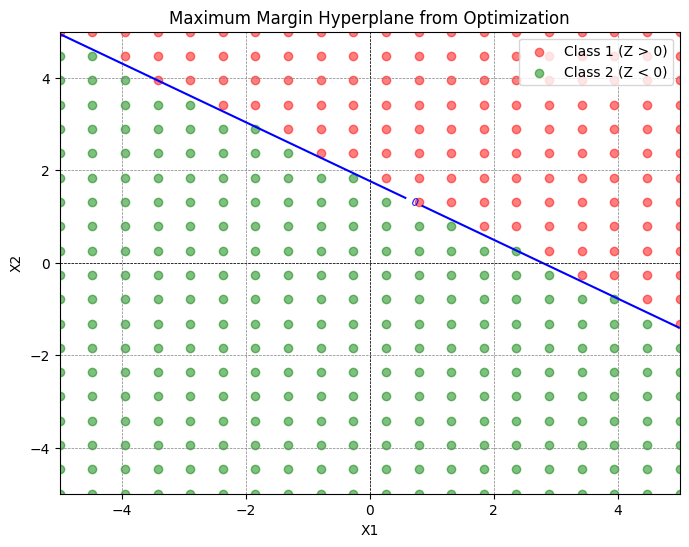

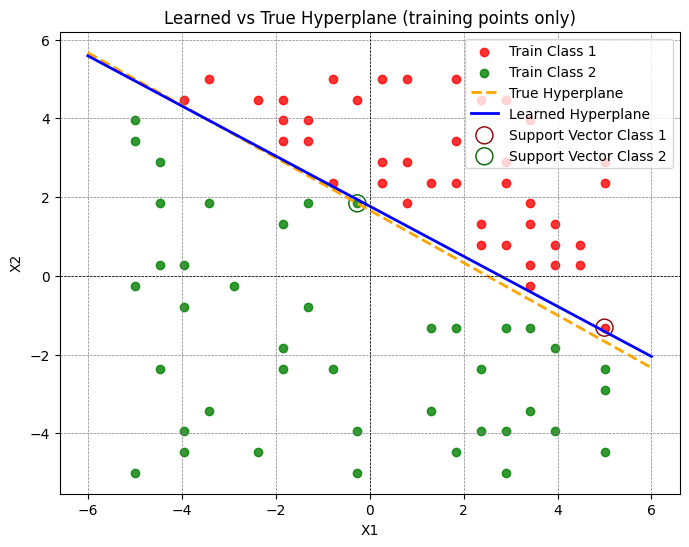

In [119]:
## Lets implement the algorithm to find the maximum margin hyperplane for a given set of points
import numpy as np
import matplotlib.pyplot as plt
# lets continue with the same grid of points and the same hyperplane as before
x1 = np.linspace(-5, 5, 20)
x2 = np.linspace(-5, 5, 20)
X1, X2 = np.meshgrid(x1, x2)
points = np.c_[X1.ravel(), X2.ravel()]
def hyperplane(x):
    return 0.4 * x[:, 0] + 0.6 * x[:, 1] - 1

# classify points based on the hyperplane
Z = hyperplane(points).reshape(X1.shape)
points_class1 = points[Z.ravel() > 0]
points_class2 = points[Z.ravel() < 0]

# select a subset of the points as training data for the maximum margin hyperplane algorithm
np.random.seed(42)  # for reproducibility
num_class1 = points_class1.shape[0]
num_class2 = points_class2.shape[0]
min_class_size = int(np.ceil(min(num_class1, num_class2) * 0.3)) # use 30% of the smaller class size for training
selected_class1 = points_class1[np.random.choice(num_class1, min_class_size, replace=False)]
selected_class2 = points_class2[np.random.choice(num_class2, min_class_size, replace=False)]

# lets construct the optimization problem to find the maximum margin hyperplane
from scipy.optimize import minimize
# prepare training set and labels (+1 / -1)
X_train = np.vstack([selected_class1, selected_class2])
y_train = np.hstack([np.ones(selected_class1.shape[0]), -np.ones(selected_class2.shape[0])])
#as minimizing ||w|| subject to the constraints that all points are classified correctly with a margin of at least M
# params = [beta0, beta1, b, M]
def objective(params):
    betas = params[:2] 
    return 0.5 * np.dot(betas, betas) # minimize 0.5 * ||w||^2 in ESL without 0.5 for numerical stability

"""
You're enforcing the standard SVM margin constraint y_i (w·x_i + b) >= 1. Brief explanation:

- The constraint in code is y_train[i] * (w·x_i + b) - 1.0 >= 0, i.e. y_i (w·x + b) >= 1.
- This fixes the scale: for any separating hyperplane you can multiply (w,b) by a constant. Requiring the margin threshold to be 1 removes that degree of freedom.
- Geometric meaning: signed distance from x to the hyperplane is y_i (w·x + b) / ||w||. If y_i (w·x + b) >= 1 then distance >= 1/||w||, so the margin equals 1/||w||.
- Minimizing 0.5 * ||w||^2 (your objective) therefore maximizes the margin 1/||w||.
- (If data are nonseparable, use slack ξ and constraints y_i(w·x+b) >= 1 - ξ_i, with a penalty C on ξ.)

So the "-1" sets the canonical margin = 1 used in the SVM primal formulation.
"""

def constraint_factory(i):
    return {
        'type': 'ineq',
        'fun': lambda params, i=i:
            y_train[i] * (np.dot(params[:2], X_train[i]) + params[2]) - 1.0 # we need a -1 here to ensure we dont get the degenerate solution w=0, b=0 which would happen if we just require y_i (w·x_i + b) >= 0 without fixing the scale
    }

# build constraints
cons = [constraint_factory(i) for i in range(X_train.shape[0])]

# initial guess [w0, w1, b]
x0 = np.zeros(3)

res = minimize(objective, x0, constraints=cons)

w_opt = res.x[:2]
b_opt = res.x[2]

print("Optimal w:", w_opt)
print("Optimal b:", b_opt)


# now we can visualize the maximum margin hyperplane found by the optimization
def max_margin_hyperplane(x):
    return w_opt[0] * x[:, 0] + w_opt[1] * x[:, 1] + b_opt

Z_max_margin = max_margin_hyperplane(points).reshape(X1.shape)
points_class1_mm = points[Z_max_margin.ravel() > 0]
points_class2_mm = points[Z_max_margin.ravel() < 0]

plt.figure(figsize=(8, 6))
contour_mm = plt.contour(X1, X2, Z_max_margin, levels=[0], colors='blue')
plt.clabel(contour_mm, inline=True, fontsize=8)
plt.scatter(points_class1_mm[:, 0], points_class1_mm[:, 1], color='red', alpha=0.5, label='Class 1 (Z > 0)')
plt.scatter(points_class2_mm[:, 0], points_class2_mm[:, 1], color='green', alpha=0.5, label='Class 2 (Z < 0)')
plt.title('Maximum Margin Hyperplane from Optimization')
plt.xlabel('X1')
plt.ylabel('X2')
plt.axhline(0, color='black',linewidth=0.5, ls='--')
plt.axvline(0, color='black',linewidth=0.5, ls='--')
plt.grid(color = 'gray', linestyle = '--', linewidth = 0.5)
plt.legend()
plt.show()

# visualize only the training data and label the true and learned hyperplanes
# recompute support vectors among the training points for clarity
def distance_to_hyperplane(x):
    return np.abs(max_margin_hyperplane(x)) / np.linalg.norm(w_opt)
dist_sel1 = distance_to_hyperplane(selected_class1)
dist_sel2 = distance_to_hyperplane(selected_class2)
support_vector1 = selected_class1[np.argmin(dist_sel1)]
support_vector2 = selected_class2[np.argmin(dist_sel2)]
# plot training points only and draw hyperplane lines with labels
plt.figure(figsize=(8, 6))
plt.scatter(selected_class1[:, 0], selected_class1[:, 1], color='red', alpha=0.8, label='Train Class 1')
plt.scatter(selected_class2[:, 0], selected_class2[:, 1], color='green', alpha=0.8, label='Train Class 2')
# x-range for drawing hyperplane lines
x_vals = np.linspace(np.min(X_train[:, 0]) - 1, np.max(X_train[:, 0]) + 1, 200)
# True hyperplane coefficients (from earlier definition: 0.4*x + 0.6*y - 1 = 0) -> a*x + b*y + c = 0
a_true, b_true, c_true = 0.4, 0.6, -1.0
if b_true != 0:
    y_true = (-a_true * x_vals - c_true) / b_true
    plt.plot(x_vals, y_true, color='orange', linestyle='--', linewidth=2, label='True Hyperplane')
# learned hyperplane from optimization: w_opt[0]*x + w_opt[1]*y + b_opt = 0
if w_opt[1] != 0:
    y_learned = (-w_opt[0] * x_vals - b_opt) / w_opt[1]
    plt.plot(x_vals, y_learned, color='blue', linestyle='-', linewidth=2, label='Learned Hyperplane')
# highlight support vectors
plt.scatter(support_vector1[0], support_vector1[1], facecolors='none', edgecolors='darkred', s=150, label='Support Vector Class 1')
plt.scatter(support_vector2[0], support_vector2[1], facecolors='none', edgecolors='darkgreen', s=150, label='Support Vector Class 2')
plt.title('Learned vs True Hyperplane (training points only)')
plt.xlabel('X1')
plt.ylabel('X2')
plt.axhline(0, color='black', linewidth=0.5, ls='--')
plt.axvline(0, color='black', linewidth=0.5, ls='--')
plt.grid(color='gray', linestyle='--', linewidth=0.5)
plt.legend()
plt.show()

## The non separable case (Soft margins)

In the previous experiments we always were able to separate the two classes and by the design or construction of our dataset we ensured that the two classes are linear separable. This is not always the case and in this cases the minimization of M would not yield a valid solution. In this case we need to allow that some points are on the "wrong" side of our hyperplane in order to find a solution which leads to the best separation between the classes allowing individual errors.

# Soft-margin SVM — idea and implementation details

When data are not linearly separable we introduce nonnegative slack variables $\xi_i \ge 0$ to allow some points to violate the margin. The canonical soft-margin primal formulation is:

$$
min_{w,b,\xi}\; \tfrac{1}{2}\lVert w\rVert^2 + C\sum_{i=1}^n \xi_i \\ 
\text{s.t. }\; y_i\,(w\cdot x_i + b) \ge 1 - \xi_i,\quad \xi_i \ge 0\;\;\forall i .
$$

Key points:
- The slack $\xi_i$ measures margin violation: $0 \le \xi_i < 1$ = inside margin but correctly classified; $\xi_i \ge 1$ = misclassified.
- $C>0$ trades off margin size vs. training errors: large $C$ → fewer violations (closer to hard margin), small $C$ → allow more violations for a larger margin.
- The $\tfrac{1}{2}$ factor is a convention (convenient for derivatives); removing it does not change the optimizer except scaling gradients.

Implementation notes (constrained optimizer):
- Add $n$ slack variables to your optimization vector (e.g. params = [w_0,...,w_{p-1}, b, \xi_1,...,\xi_n]).
- Use constraints $y_i( w\cdot x_i + b) + \xi_i - 1 \ge 0$ and bounds or constraints $\xi_i \ge 0$.
- Objective becomes $0.5 * \lVert w\rVert^2 + C \sum_i \xi_i$.



## Soft-margin SVM — idea and implementation details

When data are not linearly separable we introduce nonnegative slack variables $\xi_i \ge 0$ to allow some points to violate the margin. The canonical soft-margin primal formulation is:

$$
\min_{w,b,\xi} \; \frac{1}{2} \lVert w \rVert^2 + C \sum_{i=1}^n \xi_i \;
\text{s.t. } \; y_i (w \cdot x_i + b) \ge 1 - \xi_i, \quad \xi_i \ge 0 \; \forall i.
$$

Key points:
- The slack $\xi_i$ measures margin violation: $0 \le \xi_i < 1$ = inside margin but correctly classified; $\xi_i \ge 1$ = misclassified.
- $C > 0$ trades off margin size vs. training errors: large $C$ → fewer violations (closer to hard margin), small $C$ → allow more violations for a larger margin.
- The $\tfrac{1}{2}$ factor is a convention (convenient for derivatives); removing it does not change the optimizer except scaling gradients.

Implementation notes (constrained optimizer):
- Add $n$ slack variables to your optimization vector (e.g. `params = [w_0, ..., w_{p-1}, b, xi_1, ..., xi_n]`).
- Use constraints $y_i (w \cdot x_i + b) + \xi_i - 1 \ge 0$ and bounds or constraints $\xi_i \ge 0$.
- Objective becomes $0.5 * \lVert w \rVert^2 + C \sum_i \xi_i$.

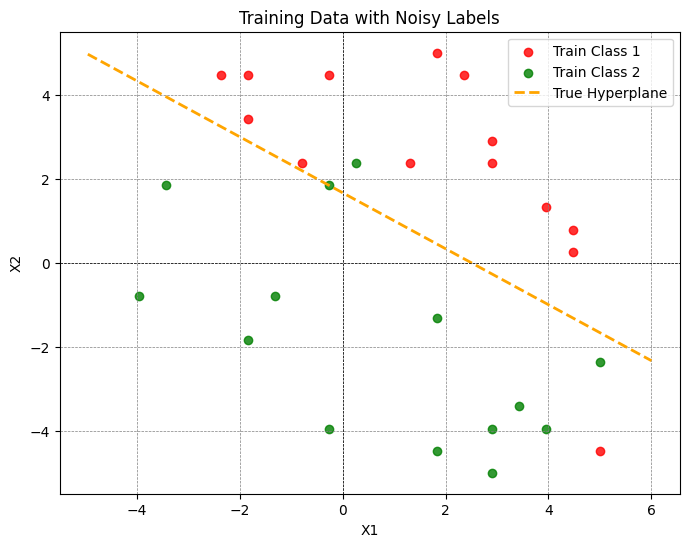

Optimal w (soft margin): [0.24918033 0.43606557]
Optimal b (soft margin): -0.3606557377105177


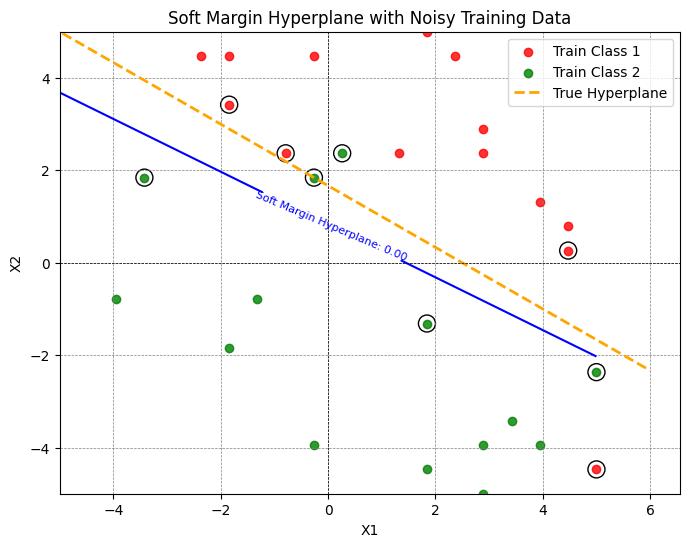

In [120]:
## Example where the two classes are not perfectly linearly separable and we need to use a soft margin classifier with slack variables


# lets generate a grid of points in 2D space as before
x1 = np.linspace(-5, 5, 20)
x2 = np.linspace(-5, 5, 20)
X1, X2 = np.meshgrid(x1, x2)
points = np.c_[X1.ravel(), X2.ravel()]
# define a hyperplane (line) in 2D space that is perfectly separating the two classes later we will add some noise to the labels to make it non-separable
def hyperplane(x):
    return 0.4 * x[:, 0] + 0.6 * x[:, 1] - 1 # same as before

# classify points based on the hyperplane first perfextly separable
Z = hyperplane(points).reshape(X1.shape)
points_class1 = points[Z.ravel() > 0]
points_class2 = points[Z.ravel() < 0]
# now we add some noise to the labels to make it non-separable
np.random.seed(42)  # for reproducibility
num_points = points.shape[0]
# lets subselect a random subset as training data and add noise to the labels of the training data
# lets select a balanced subset from both classes
num_class1 = points_class1.shape[0]
num_class2 = points_class2.shape[0]
min_class_size = int(np.ceil(min(num_class1, num_class2) * 0.1)) # use 10% of the smaller class size for training
np.random.seed(42)  # for reproducibility
selected_class1 = points_class1[np.random.choice(num_class1, min_class_size, replace=False)]
selected_class2 = points_class2[np.random.choice(num_class2, min_class_size, replace=False)]
selected_indices = np.vstack([selected_class1, selected_class2])
X_train = selected_indices # training data points
# true labels
y_train = np.where(hyperplane(X_train) > 0, 1, -1)
# add noise to 10% of the training labels for both classes
num_noisy = int(0.1 * y_train.shape[0])
noisy_indices = np.random.choice(y_train.shape[0], num_noisy, replace=False)
y_train[noisy_indices] *= -1 # flip the labels to introduce noise
# lets plot the training data with noisy labels and the true hyperplane
plt.figure(figsize=(8, 6))
plt.scatter(X_train[y_train == 1][:, 0], X_train[y_train == 1][:, 1], color='red', alpha=0.8, label='Train Class 1')
plt.scatter(X_train[y_train == -1][:, 0], X_train[y_train == -1][:, 1], color='green', alpha=0.8, label='Train Class 2')
# plot the true hyperplane
x_vals = np.linspace(np.min(X_train[:, 0]) - 1, np.max(X_train[:, 0]) + 1, 200)
a_true, b_true, c_true = 0.4, 0.6, -1.0
if b_true != 0:
    y_true = (-a_true * x_vals - c_true) / b_true
    plt.plot(x_vals, y_true, color='orange', linestyle='--', linewidth=2, label='True Hyperplane')
plt.title('Training Data with Noisy Labels')
plt.xlabel('X1')
plt.ylabel('X2')
plt.axhline(0, color='black', linewidth=0.5, ls='--')
plt.axvline(0, color='black', linewidth=0.5, ls='--')
plt.grid(color='gray', linestyle='--', linewidth=0.5)
plt.legend()
plt.show()


# Now we can consatruct the optimization problem to find the soft margin maximum margin hyperplane with slack variables
from scipy.optimize import minimize
# params = [beta0, beta1, b, xi_1, xi_2, ..., xi_n]
# C is the penalty parameter for the slack variables 
# higher C means higher penalty for misclassification and smaller margin
# with C=0 we come back to the hard margin case as before, a larger C means we allow more slack and thus a larger margin
C = .1
def objective_soft_margin(params):
    betas = params[:2]
    xi = params[3:] # slack variables for each training point
    return 0.5 * np.dot(betas, betas) + C * np.sum(xi) # minimize 0.5 * ||w||^2 + C * sum(xi)

# now construct the constraints for the soft margin SVM by adding the slack variables to the margin constraints
def constraint_factory_soft_margin(i):
    return {
        'type': 'ineq',
        'fun': lambda params, i=i:
            y_train[i] * (np.dot(params[:2], X_train[i]) + params[2]) - 1.0 + params[3 + i] # we add the slack variable for the i-th training point to allow for margin violation
    }
# we also need to add constraints to ensure that the slack variables are non-negative
def slack_non_negative_factory(i):
    return {
        'type': 'ineq',
        'fun': lambda params, i=i:
            params[3 + i] # slack variable for the i-th training point must be >= 0
    }
    
# build constraints
cons_soft_margin = [constraint_factory_soft_margin(i) for i in range(X_train.shape[0])]
cons_soft_margin += [slack_non_negative_factory(i) for i in range(X_train.shape[0])]
# initial guess [w0, w1, b, xi_1, xi_2, ..., xi_n]
x0_soft_margin = np.zeros(3 + X_train.shape[0]) # initial guess for optimization all slack variables start at 0 --> hard margin solution and all betas start at 0 --> degenerate solution but the optimization will find a better solution from there
res_soft_margin = minimize(objective_soft_margin, x0_soft_margin, constraints=cons_soft_margin)
w_opt_sm = res_soft_margin.x[:2]
b_opt_sm = res_soft_margin.x[2]
xi_opt_sm = res_soft_margin.x[3:] # optimal slack variables

print("Optimal w (soft margin):", w_opt_sm)
print("Optimal b (soft margin):", b_opt_sm)
#print("Optimal slack variables (soft margin):", xi_opt_sm) # these slack variables indicate how much each training point violates the margin constraint, with xi_i > 0 indicating a margin violation for the i-th training point
# now we can visualize the soft margin hyperplane found by the optimization
def soft_margin_hyperplane(x):
    return w_opt_sm[0] * x[:, 0] + w_opt_sm[1] * x[:, 1] + b_opt_sm


# lets visualize the soft margin hyperplane along with the training points and highlight the points that are violating the margin (i.e. points with xi_i > 0)
Z_soft_margin = soft_margin_hyperplane(points).reshape(X1.shape)
points_class1_sm = points[Z_soft_margin.ravel() > 0]
points_class2_sm = points[Z_soft_margin.ravel() < 0]
plt.figure(figsize=(8, 6))
contour_sm = plt.contour(X1, X2, Z_soft_margin, levels=[0], colors='blue')
plt.clabel(contour_sm, inline=True, fontsize=8, fmt='Soft Margin Hyperplane: %.2f') # add label to contour line with the equation of the hyperplane
# just plot the training points with noisy labels to see how the soft margin hyperplane is fitting the data
plt.scatter(X_train[y_train == 1][:, 0], X_train[y_train == 1][:, 1], color='red', alpha=0.8, label='Train Class 1')
plt.scatter(X_train[y_train == -1][:, 0], X_train[y_train == -1][:, 1], color='green', alpha=0.8, label='Train Class 2')
# highlight points that are violating the margin (xi_i > 0) with a black edge
for i in range(X_train.shape[0]):
    if xi_opt_sm[i] > 1e-5: # consider a small threshold to account for numerical precision
        plt.scatter(X_train[i, 0], X_train[i, 1], facecolors='none', edgecolors='black', s=150, label='Margin Violation' if i == 0 else "") # only add label for the first violation to avoid duplicate legend entries
# plot the true hyperplane for reference
x_vals = np.linspace(np.min(X_train[:, 0]) - 1, np.max(X_train[:, 0]) + 1, 200)
a_true, b_true, c_true = 0.4, 0.6, -1.0
if b_true != 0:
    y_true = (-a_true * x_vals - c_true) / b_true
    plt.plot(x_vals, y_true, color='orange', linestyle='--', linewidth=2, label='True Hyperplane')
plt.title('Soft Margin Hyperplane with Noisy Training Data')
plt.xlabel('X1')
plt.ylabel('X2')
plt.axhline(0, color='black', linewidth=0.5, ls='--')
plt.axvline(0, color='black', linewidth=0.5, ls='--')
plt.grid(color='gray', linestyle='--', linewidth=0.5)
plt.legend()
plt.show()

## Support Vector Machine (SVM) — Primal and Dual Formulation with Lagrange Multipliers

### 1. Primal Problem (Maximum Margin Hyperplane)

Given a training set  

$$
\{(x_i, y_i)\}_{i=1}^n, \quad x_i \in \mathbb{R}^p,\; y_i \in \{-1,+1\}
$$

we want to find the separating hyperplane

$$
w^T x + b = 0
$$

that maximizes the margin.  
This is equivalent to minimizing the squared norm of $w$.

#### Optimization problem (Primal)

$$
\min_{w,b} \quad \frac{1}{2}\|w\|^2
$$

subject to

$$
y_i \big(w^T x_i + b\big) \ge 1, \quad \forall i=1,\dots,n
$$

This is called the **primal formulation** because we directly optimize the model parameters $w$ and $b$.

> **Intuition**  
> The constraint enforces correct classification with a margin of at least 1.  
> Minimizing $\|w\|$ maximizes the geometric margin $2/\|w\|$.

---

### 2. Lagrangian Formulation

To incorporate the constraints, we introduce **Lagrange multipliers**  
$\alpha_i \ge 0$ for each constraint.

#### Lagrangian

$$
\mathcal{L}(w,b,\alpha)
=
\frac{1}{2}\|w\|^2
-
\sum_{i=1}^n
\alpha_i \Big[
y_i (w^T x_i + b) - 1
\Big]
$$

---

> **Hint — Lagrange Multipliers**  
> Lagrange multipliers measure how strongly a constraint influences the optimum.  
> If a constraint is inactive (point far from margin), its multiplier becomes 0.  
> Points with $\alpha_i>0$ lie on the margin → **support vectors**.

---

### 3. From Primal to Dual

The dual problem is obtained by

1. Minimizing the Lagrangian w.r.t. $w$ and $b$  
2. Substituting the result back into $\mathcal{L}$

This eliminates $w,b$ and yields a problem in $\alpha$ only.

---

#### Step 1 — Derivative w.r.t. $w$

$$
\frac{\partial \mathcal{L}}{\partial w}
=
w - \sum_{i=1}^n \alpha_i y_i x_i
= 0
$$

$$
\Rightarrow
w = \sum_{i=1}^n \alpha_i y_i x_i
$$

---

#### Step 2 — Derivative w.r.t. $b$

$$
\frac{\partial \mathcal{L}}{\partial b}
=
-\sum_{i=1}^n \alpha_i y_i = 0
$$

$$
\Rightarrow
\sum_{i=1}^n \alpha_i y_i = 0
$$

---

### 4. Substituting back into the Lagrangian

Start with

$$
\mathcal{L}
=
\frac{1}{2} w^T w
-
\sum_i \alpha_i y_i (w^T x_i)
-
b\sum_i \alpha_i y_i
+
\sum_i \alpha_i
$$

The third term vanishes because  

$$
\sum_i \alpha_i y_i = 0
$$

---

#### Expand $w^T w$

$$
w^T w
=
\left(\sum_i \alpha_i y_i x_i\right)^T
\left(\sum_j \alpha_j y_j x_j\right)
=
\sum_{i,j}
\alpha_i \alpha_j y_i y_j x_i^T x_j
$$

---

#### Expand the second term

$$
\sum_i \alpha_i y_i (w^T x_i)
=
\sum_{i,j}
\alpha_i \alpha_j y_i y_j x_i^T x_j
$$

---

#### Combine terms

$$
\mathcal{L}(\alpha)
=
\sum_{i=1}^n \alpha_i
-
\frac{1}{2}
\sum_{i=1}^n
\sum_{j=1}^n
\alpha_i \alpha_j y_i y_j x_i^T x_j
$$

---

### 5. Dual Optimization Problem

$$
\max_{\alpha}
\quad
\sum_{i=1}^n \alpha_i
-
\frac{1}{2}
\sum_{i,j}
\alpha_i \alpha_j y_i y_j x_i^T x_j
$$

subject to

$$
\alpha_i \ge 0, \quad
\sum_i \alpha_i y_i = 0
$$

---

> **Hint — Dual vs Primal**
>
> **Primal**
> - Optimize directly over $w,b$
> - Dimension depends on feature space $p$
>
> **Dual**
> - Optimize over $\alpha$
> - Dimension depends on number of samples $n$
> - Enables kernels because only inner products appear

---

### 6. Interpretation of the Final Formula

The quadratic term

$$
\sum_{i,j} \alpha_i \alpha_j y_i y_j x_i^T x_j
$$

is a **quadratic form** capturing pairwise interactions.

> **Intuition**
>
> - Same label ($y_i=y_j$) → positive contribution  
> - Opposite labels → negative contribution  
> - Larger inner product → stronger interaction  
>
> Only points with $\alpha_i>0$ remain → **support vectors**

---

### 7. Recovering the Hyperplane

After solving the dual:

$$
w = \sum_i \alpha_i y_i x_i
$$

$$
b = y_k - w^T x_k
\quad \text{for any support vector } k
$$

---

### 8. Gram Matrix

Define

$$
K_{ij} = x_i^T x_j
$$

Then the dual becomes

$$
\max_\alpha
\quad
\sum_i \alpha_i
-
\frac{1}{2}
\sum_{i,j}
\alpha_i \alpha_j y_i y_j K_{ij}
$$

---

> **Hint — Gram Matrix**
>
> - Stores all pairwise inner products  
> - Symmetric and positive semidefinite  
> - Represents geometry of data in feature space  
>
> **Key insight (ESL):**  
> SVM depends only on inner products →  
> we can replace them with a kernel  
>
> $$
> K(x_i,x_j)=\phi(x_i)^T\phi(x_j)
> $$
>
> without explicitly computing $\phi(x)$

---

### 9. Why the Dual is Numerically Attractive

- Quadratic programming with linear constraints  
- Works well when $p \gg n$  
- Enables nonlinear decision boundaries via kernels  

---

## Summary

1. Start with margin maximization → primal problem  
2. Introduce Lagrange multipliers → enforce constraints  
3. Minimize over $w,b$ → express solution via data  
4. Obtain quadratic program in $\alpha$  
5. Only support vectors define the classifier  


Optimal alpha: [-2.00073329e-15  6.10980859e-15  2.22416658e-15  8.60623966e-01
 -1.39916481e-15 -3.80179117e-15  3.93068210e-15  4.42626820e-17
  3.34497540e-15  9.43312828e-16  6.83442625e-01  4.94901186e-15
 -4.70848818e-15  4.19341429e-15  2.57476841e-15  9.89517049e-16
  1.54406659e+00 -3.63248034e-15  4.82943113e-15 -8.61186631e-16
  4.07469431e-16  6.96725082e-15]
Optimal w (dual): [1.12502508 1.34998516]
Optimal b (dual): -2.624974423452386


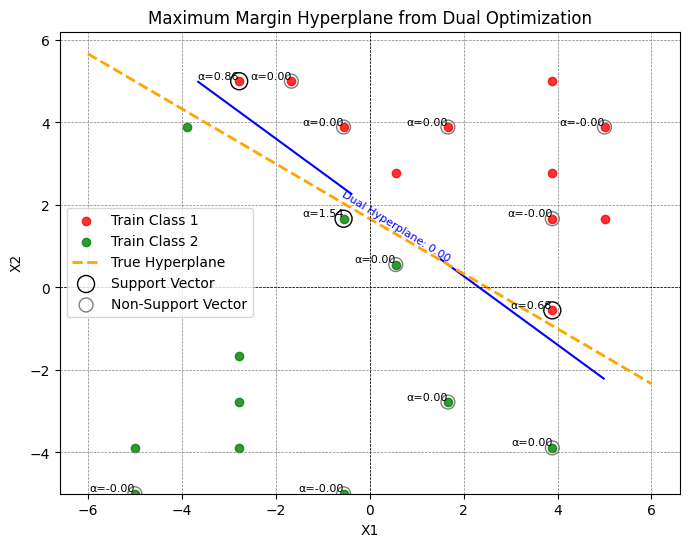

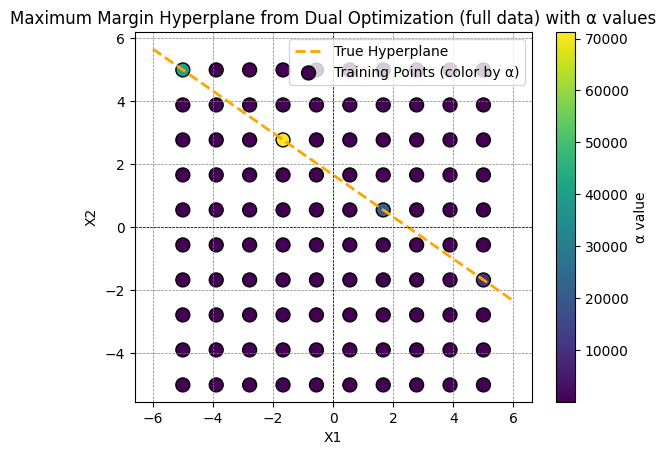

In [121]:
## Example of a maximum margin classifiert derived using the langrangian formulation of the optimization problem  instead of the primal formulation as before

# generte a grid of points in 2D space as before
x1 = np.linspace(-5, 5, 10)
x2 = np.linspace(-5, 5, 10)
X1, X2 = np.meshgrid(x1, x2)
points = np.c_[X1.ravel(), X2.ravel()]

# define a hyperplane (line) in 2D space
def hyperplane(x):
    return 0.4 * x[:, 0] + 0.6 * x[:, 1] - 1 # same as before

# classify points based on the hyperplane
Z = hyperplane(points).reshape(X1.shape)
points_class1 = points[Z.ravel() > 0]
points_class2 = points[Z.ravel() < 0]
# select a subset of the points as training data for the maximum margin hyperplane algorithm
np.random.seed(42)  # for reproducibility
num_class1 = points_class1.shape[0]
num_class2 = points_class2.shape[0]
min_class_size = int(np.ceil(min(num_class1, num_class2) * 0.3)) # use 30% of the smaller class size for training
selected_class1 = points_class1[np.random.choice(num_class1, min_class_size, replace=False)]
selected_class2 = points_class2[np.random.choice(num_class2, min_class_size, replace=False)]
X_train = np.vstack([selected_class1, selected_class2])
y_train = np.hstack([np.ones(selected_class1.shape[0]), -np.ones(selected_class2.shape[0])])
# now we can construct the optimization problem using the lagrangian formulation of the SVM optimization problem
# recall the dual optimization problem for the hard margin SVM is:
# maximize L(alpha) = sum_i alpha_i - 0.5 * sum_i sum_j alpha_i alpha_j y_i y_j (x_i · x_j)

# now with subject to alpha_i >= 0 for all i and sum_i alpha_i y_i = 0
from scipy.optimize import minimize

def make_dual_objective(X, y):
    K = np.dot(X, X.T)  # kernel matrix for linear SVM
    def objective(alpha):
        L = np.sum(alpha) - 0.5 * np.sum(alpha[:, None] * alpha[None, :] * y[:, None] * y[None, :] * K)
        return -L  # minimize -L to maximize L
    return objective

def make_constraints(n, y):
    # inequality constraints alpha_i >= 0
    cons = [{'type': 'ineq', 'fun': (lambda i: (lambda a: a[i]))(i)} for i in range(n)]
    # equality constraint sum_i alpha_i y_i = 0
    cons.append({'type': 'eq', 'fun': lambda a, y=y: np.sum(a * y)})
    return cons

# build objective & constraints for current training subset
obj_dual = make_dual_objective(X_train, y_train)
cons_dual = make_constraints(X_train.shape[0], y_train)
# initial guess for alpha
x0_dual = np.zeros(X_train.shape[0])  # start with all alpha_i = 0
res_dual = minimize(obj_dual, x0_dual, constraints=cons_dual)
alpha_opt = res_dual.x
print("Optimal alpha:", alpha_opt)
# now compute optimal w and b from optimal alpha
w_opt_dual = np.sum(alpha_opt[:, None] * y_train[:, None] * X_train, axis=0)  # w = sum_i alpha_i y_i x_i
# for any support vector x_i with alpha_i > 0, y_i (w · x_i + b) = 1
support_vector_indices = np.where(alpha_opt > 1e-5)[0]  # threshold for numerical precision
b_opt_dual = np.mean(y_train[support_vector_indices] - np.dot(X_train[support_vector_indices], w_opt_dual))  # stable estimate
print("Optimal w (dual):", w_opt_dual)
print("Optimal b (dual):", b_opt_dual)
# hyperplane from dual solution
def hyperplane_dual(x):
    return w_opt_dual[0] * x[:, 0] + w_opt_dual[1] * x[:, 1] + b_opt_dual

# support vectors from the training subset
support_vectors_dual = X_train[alpha_opt > 1e-5]



# now we can visualize the maximum margin hyperplane vs. the true hyperplane along with the training points
Z_dual = hyperplane_dual(points).reshape(X1.shape)
points_class1_dual = points[Z_dual.ravel() > 0]
points_class2_dual = points[Z_dual.ravel() < 0]
plt.figure(figsize=(8, 6))
contour_dual = plt.contour(X1, X2, Z_dual, levels=[0], colors='blue')
plt.clabel(contour_dual, inline=True, fontsize=8, fmt='Dual Hyperplane: %.2f') # add label to contour line with the equation of the hyperplane
# just plot the training points to see how the dual hyperplane is fitting the data
plt.scatter(X_train[y_train == 1][:, 0], X_train[y_train == 1][:, 1], color='red', alpha=0.8, label='Train Class 1')
plt.scatter(X_train[y_train == -1][:, 0], X_train[y_train == -1][:, 1], color='green', alpha=0.8, label='Train Class 2')
# plot the true hyperplane for reference
x_vals = np.linspace(np.min(X_train[:, 0]) - 1, np.max(X_train[:, 0]) + 1, 200)
a_true, b_true, c_true = 0.4, 0.6, -1.0
if b_true != 0:
    y_true = (-a_true * x_vals - c_true) / b_true
    plt.plot(x_vals, y_true, color='orange', linestyle='--', linewidth=2, label='True Hyperplane')
    
# highlight support vectors and notate the alpha values for the support vectors
for i in support_vector_indices:
    plt.scatter(X_train[i, 0], X_train[i, 1], facecolors='none', edgecolors='black', s=150, label='Support Vector' if i == support_vector_indices[0] else "") # only add label for the first support vector to avoid duplicate legend entries
    plt.text(X_train[i, 0], X_train[i, 1], f'α={alpha_opt[i]:.2f}', fontsize=8, ha='right', va='bottom') # annotate alpha values for support vectors

# randomly select a subset of the non-support vectors to plot with lower alpha values for clarity
non_support_vector_indices = np.where(alpha_opt <= 1e-5)[0]
num_non_support_to_plot = min(10, len(non_support_vector_indices)) # plot at most 10 non-support vectors for clarity
selected_non_support_indices = np.random.choice(non_support_vector_indices, num_non_support_to_plot, replace=False)
for i in selected_non_support_indices:
    plt.scatter(X_train[i, 0], X_train[i, 1], facecolors='none', edgecolors='gray', s=100, label='Non-Support Vector' if i == selected_non_support_indices[0] else "") # only add label for the first non-support vector to avoid duplicate legend entries
    plt.text(X_train[i, 0], X_train[i, 1], f'α={alpha_opt[i]:.2f}', fontsize=8, ha='right', va='bottom') # annotate alpha values for non-support vectors
plt.title('Maximum Margin Hyperplane from Dual Optimization')
plt.xlabel('X1')
plt.ylabel('X2')
plt.axhline(0, color='black', linewidth=0.5, ls='--')
plt.axvline(0, color='black', linewidth=0.5, ls='--')
plt.grid(color='gray', linestyle='--', linewidth=0.5)
plt.legend()
plt.show()


# now use all data points to train the dual SVM and visualize the resulting hyperplane and show the alpha values for all points as heatmap
# prepare the full training set and labels
X_train_full = points
y_train_full = np.where(hyperplane(X_train_full) > 0, 1, -1)
# build constraints for the full training set
# now use all data points to train the dual SVM and visualize the resulting hyperplane and show the alpha values for all points as heatmap
# prepare the full training set and labels
X_train_full = points
y_train_full = np.where(hyperplane(X_train_full) > 0, 1, -1)
# build objective & constraints for the full training set
obj_dual_full = make_dual_objective(X_train_full, y_train_full)
cons_dual_full = make_constraints(X_train_full.shape[0], y_train_full)
# initial guess for alpha
x0_dual_full = np.zeros(X_train_full.shape[0])  # start with all zeros
res_dual_full = minimize(obj_dual_full, x0_dual_full, constraints=cons_dual_full)
alpha_opt_full = res_dual_full.x
w_opt_dual_full = np.sum(alpha_opt_full[:, None] * y_train_full[:, None] * X_train_full, axis=0)  # w = sum_i alpha_i y_i x_i
b_opt_dual_full = np.mean(y_train_full[alpha_opt_full > 1e-5] - np.dot(X_train_full[alpha_opt_full > 1e-5], w_opt_dual_full))  # stable estimate
def hyperplane_dual_full(x):
    return w_opt_dual_full[0] * x[:, 0] + w_opt_dual_full[1] * x[:, 1] + b_opt_dual_full
Z_dual_full = hyperplane_dual_full(points).reshape(X1.shape)
a_true, b_true, c_true = 0.4, 0.6, -1.0
if b_true != 0:
    y_true = (-a_true * x_vals - c_true) / b_true
    plt.plot(x_vals, y_true, color='orange', linestyle='--', linewidth=2, label='True Hyperplane')

# now plot the alpha values for all points as a heatmap
scatter = plt.scatter(X_train_full[:, 0], X_train_full[:, 1], c=alpha_opt_full, cmap='viridis', edgecolors='black', s=100, label='Training Points (color by α)')
plt.colorbar(scatter, label='α value') # add colorbar to indicate alpha values
plt.title('Maximum Margin Hyperplane from Dual Optimization (full data) with α values')
plt.xlabel('X1')
plt.ylabel('X2')
plt.axhline(0, color='black', linewidth=0.5, ls='--')
plt.axvline(0, color='black', linewidth=0.5, ls='--')
plt.grid(color='gray', linestyle='--', linewidth=0.5)
plt.legend()
plt.show()



# Support Vector Machine - Expanding to non linearity and introducing the kernel trick

So far we were assuming always that the two classes within y are linear separable in their feature space x. With the introduction of the softmargin classifier we introduced a method to handle non perfect linear separable classes by adding soft margins and introducing slack variables. 

In reality classes separation in the feature space is non linear. The next example shows the prediction of a softmargin classifier on a linear dataset.

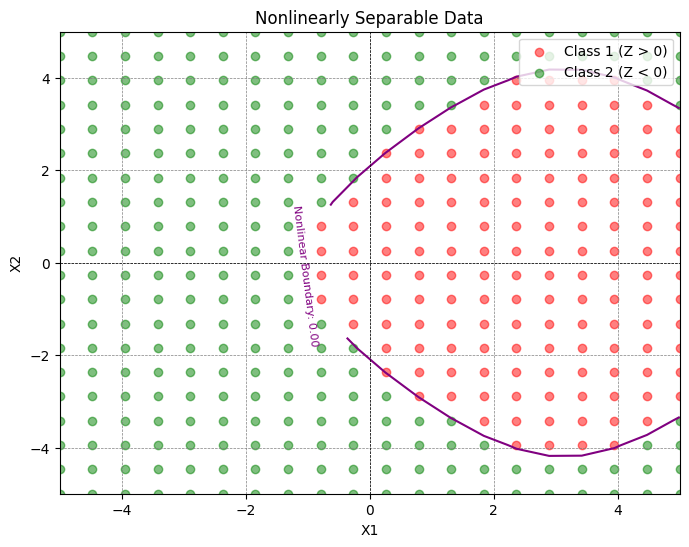

Optimal w (soft margin): [3.80000000e-01 8.91213665e-12]
Optimal b (soft margin): -0.10000000006126836


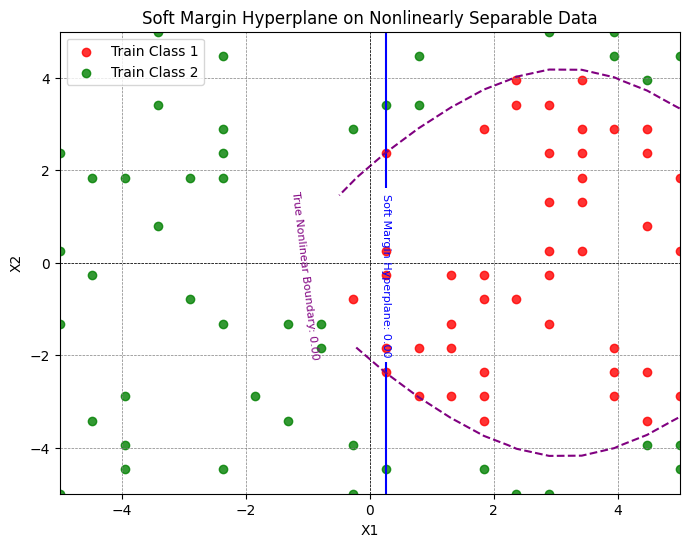

In [122]:
# generate a grid of points in 2D space as before
x1 = np.linspace(-5, 5, 20)
x2 = np.linspace(-5, 5, 20)
X1, X2 = np.meshgrid(x1, x2)
points = np.c_[X1.ravel(), X2.ravel()]
# make them non-linearly separable by using a non-linear function to define the classes instead of a linear hyperplane
def nonlinear_function(x):
    return np.sin(0.5 * x[:, 0]) + np.cos(0.5 * x[:, 1]) - 0.5

Z_nonlinear = nonlinear_function(points).reshape(X1.shape)
points_class1_nl = points[Z_nonlinear.ravel() > 0]
points_class2_nl = points[Z_nonlinear.ravel() < 0]
plt.figure(figsize=(8, 6))
contour_nl = plt.contour(X1, X2, Z_nonlinear, levels=[0], colors='purple')
plt.clabel(contour_nl, inline=True, fontsize=8, fmt='Nonlinear Boundary: %.2f') # add label to contour line with the equation of the nonlinear boundary
plt.scatter(points_class1_nl[:, 0], points_class1_nl[:, 1], color='red', alpha=0.5, label='Class 1 (Z > 0)')
plt.scatter(points_class2_nl[:, 0], points_class2_nl[:, 1], color='green', alpha=0.5, label='Class 2 (Z < 0)')
plt.title('Nonlinearly Separable Data')
plt.xlabel('X1')
plt.ylabel('X2')
plt.axhline(0, color='black', linewidth=0.5, ls='--')
plt.axvline(0, color='black', linewidth=0.5, ls='--')
plt.grid(color='gray', linestyle='--', linewidth=0.5)
plt.legend()
plt.show()

# now try to fit a linear soft margin classifier to this non-linearly separable data and visualize the resulting hyperplane

# prepare training set and labels for the non-linear data using a random subset for training
np.random.seed(42)  # for reproducibility
num_class1_nl = points_class1_nl.shape[0]
num_class2_nl = points_class2_nl.shape[0]
min_class_size_nl = int(np.ceil(min(num_class1_nl, num_class2_nl) * 0.3)) # use 30% of the smaller class size for training
selected_class1_nl = points_class1_nl[np.random.choice(num_class1_nl, min_class_size_nl, replace=False)]
selected_class2_nl = points_class2_nl[np.random.choice(num_class2_nl, min_class_size_nl, replace=False)]
X_train = np.vstack([selected_class1_nl, selected_class2_nl])
y_train = np.hstack([np.ones(selected_class1_nl.shape[0]), -np.ones(selected_class2_nl.shape[0])])

# Now we can consatruct the optimization problem to find the soft margin maximum margin hyperplane with slack variables
from scipy.optimize import minimize
# params = [beta0, beta1, b, xi_1, xi_2, ..., xi_n]
# C is the penalty parameter for the slack variables 
# higher C means higher penalty for misclassification and smaller margin
# with C=0 we come back to the hard margin case as before, a larger C means we allow more slack and thus a larger margin
C = 1
def objective_soft_margin(params):
    betas = params[:2]
    xi = params[3:] # slack variables for each training point
    return 0.5 * np.dot(betas, betas) + C * np.sum(xi) # minimize 0.5 * ||w||^2 + C * sum(xi)

# now construct the constraints for the soft margin SVM by adding the slack variables to the margin constraints
def constraint_factory_soft_margin(i):
    return {
        'type': 'ineq',
        'fun': lambda params, i=i:
            y_train[i] * (np.dot(params[:2], X_train[i]) + params[2]) - 1.0 + params[3 + i] # we add the slack variable for the i-th training point to allow for margin violation
    }
# we also need to add constraints to ensure that the slack variables are non-negative
def slack_non_negative_factory(i):
    return {
        'type': 'ineq',
        'fun': lambda params, i=i:
            params[3 + i] # slack variable for the i-th training point must be >= 0
    }
    
# build constraints
cons_soft_margin = [constraint_factory_soft_margin(i) for i in range(X_train.shape[0])]
cons_soft_margin += [slack_non_negative_factory(i) for i in range(X_train.shape[0])]
# initial guess [w0, w1, b, xi_1, xi_2, ..., xi_n]
x0_soft_margin = np.zeros(3 + X_train.shape[0]) # initial guess for optimization all slack variables start at 0 --> hard margin solution and all betas start at 0 --> degenerate solution but the optimization will find a better solution from there
res_soft_margin = minimize(objective_soft_margin, x0_soft_margin, constraints=cons_soft_margin)
w_opt_sm = res_soft_margin.x[:2]
b_opt_sm = res_soft_margin.x[2]
xi_opt_sm = res_soft_margin.x[3:] # optimal slack variables

print("Optimal w (soft margin):", w_opt_sm)
print("Optimal b (soft margin):", b_opt_sm)

# now we can visualize the soft margin hyperplane found by the optimization
def soft_margin_hyperplane(x):
    return w_opt_sm[0] * x[:, 0] + w_opt_sm[1] * x[:, 1] + b_opt_sm
Z_soft_margin = soft_margin_hyperplane(points).reshape(X1.shape)
points_class1_sm = points[Z_soft_margin.ravel() > 0]
points_class2_sm = points[Z_soft_margin.ravel() < 0]
plt.figure(figsize=(8, 6))
contour_sm = plt.contour(X1, X2, Z_soft_margin, levels=[0], colors='blue')
plt.clabel(contour_sm, inline=True, fontsize=8, fmt='Soft Margin Hyperplane: %.2f') # add label to contour line with the equation of the hyperplane
# just plot the training points with noisy labels to see how the soft margin hyperplane is fitting the data
plt.scatter(X_train[y_train == 1][:, 0], X_train[y_train == 1][:, 1], color='red', alpha=0.8, label='Train Class 1')
plt.scatter(X_train[y_train == -1][:, 0], X_train[y_train == -1][:, 1], color='green', alpha=0.8, label='Train Class 2')
# plot the true nonlinear boundary for reference
Z_nonlinear = nonlinear_function(points).reshape(X1.shape)
contour_nl = plt.contour(X1, X2, Z_nonlinear, levels=[0], colors='purple', linestyles='--')
plt.clabel(contour_nl, inline=True, fontsize=8, fmt='True Nonlinear Boundary: %.2f') # add label to contour line with the equation of the nonlinear boundary
plt.title('Soft Margin Hyperplane on Nonlinearly Separable Data')
plt.xlabel('X1')
plt.ylabel('X2')
plt.axhline(0, color='black', linewidth=0.5, ls='--')
plt.axvline(0, color='black', linewidth=0.5, ls='--')
plt.grid(color='gray', linestyle='--', linewidth=0.5)
plt.legend()
plt.show()

Separation of the two classes with a reasonable performance is not possible as the model flexibility is not given. One trick to enhance the flexibility of the decision boundaries is to introduce non linear feature combinations in the feature space like polynomials. Recalling polynomial regression higher degrees of freedom allows to achieve more flexible decision boundaries. 

Therefor we expand the feature space of our example consisting of x1, x2 and a bias term 1

to a polynomial combination with degree p=2 leading to the new feature space

$$
 x_1^2 + x_2^2 + 2x_1 + 2x_2 + 2x_1 x_2 + 1 
$$

Applying this polynomial expansion to the soft margin classifier yields

Optimal betas (polynomial kernel): [ 2.40310245 -0.00411255 -0.41152958 -0.32818182  0.01562771]
Optimal b (polynomial kernel): 2.2213852822586033


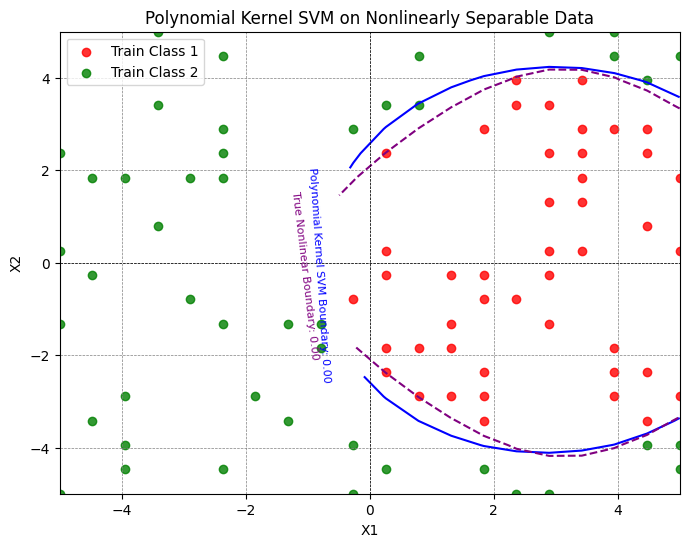

In [123]:
## now we use a polynomial kernel to fit a non-linear SVM to the same non-linearly separable data and visualize the resulting decision boundary
import numpy as np
import matplotlib.pyplot as plt
# polynomial of degree 2 to transform the data into a higher dimensional space where it is linearly separable
def polynomial_kernel(x):
    # transform (x1, x2) to (x1, x2, x1^2, x2^2, x1*x2 + constant) to allow for non-linear decision boundary in the original space
    return np.c_[x, x[:, 0]**2, x[:, 1]**2, x[:, 0] * x[:, 1] + 1]

# generate the datatset again to ensure we have the same non-linear data
x1 = np.linspace(-5, 5, 20)
x2 = np.linspace(-5, 5, 20)
X1, X2 = np.meshgrid(x1, x2)
points = np.c_[X1.ravel(), X2.ravel()]
def nonlinear_function(x):
    return np.sin(0.5 * x[:, 0]) + np.cos(0.5 * x[:, 1]) - 0.5

Z_nonlinear = nonlinear_function(points).reshape(X1.shape)
points_class1_nl = points[Z_nonlinear.ravel() > 0]
points_class2_nl = points[Z_nonlinear.ravel() < 0]
# prepare training set and labels for the non-linear data using a random subset for training
np.random.seed(42)  # for reproducibility
num_class1_nl = points_class1_nl.shape[0]
num_class2_nl = points_class2_nl.shape[0]
min_class_size_nl = int(np.ceil(min(num_class1_nl, num_class2_nl) * 0.3)) # use 30% of the smaller class size for training
selected_class1_nl = points_class1_nl[np.random.choice(num_class1_nl, min_class_size_nl, replace=False)]
selected_class2_nl = points_class2_nl[np.random.choice(num_class2_nl, min_class_size_nl, replace=False)]
X_train = np.vstack([selected_class1_nl, selected_class2_nl])
y_train = np.hstack([np.ones(selected_class1_nl.shape[0]), -np.ones(selected_class2_nl.shape[0])])
# transform the training data using the polynomial kernel
X_train_poly = polynomial_kernel(X_train)
# Now we can consatruct the optimization problem to find the soft margin maximum margin hyperplane with slack variables in the transformed space
from scipy.optimize import minimize
# params = [beta0, beta1, beta2, beta3, beta4, b, xi_1, xi_2, ..., xi_n] for the polynomial kernel with 5 features (x1, x2, x1^2, x2^2, x1*x2 + 1)
# C is the penalty parameter for the slack variables
C = 1
def objective_soft_margin_poly(params):
    betas = params[:5] # 5 features from the polynomial kernel
    xi = params[6:] # slack variables for each training point
    return 0.5 * np.dot(betas, betas) + C * np.sum(xi) # minimize 0.5 * ||w||^2 + C * sum(xi)
# now construct the constraints for the soft margin SVM by adding the slack variables to the margin constraints in the transformed space
def constraint_factory_soft_margin_poly(i):
    return {
        'type': 'ineq',
        'fun': lambda params, i=i:
            y_train[i] * (np.dot(params[:5], X_train_poly[i]) + params[5]) - 1.0 + params[6 + i] # we add the slack variable for the i-th training point to allow for margin violation
    }
# we also need to add constraints to ensure that the slack variables are non-negative
def slack_non_negative_factory_poly(i):
    return {
        'type': 'ineq',
        'fun': lambda params, i=i:
            params[6 + i] # slack variable for the i-th training point must be >= 0
    }
    
# build constraints
cons_soft_margin_poly = [constraint_factory_soft_margin_poly(i) for i in range(X_train.shape[0])]
cons_soft_margin_poly += [slack_non_negative_factory_poly(i) for i in range(X_train.shape[0])]
# initial guess [w0, w1, w2, w3, w4, b, xi_1, xi_2, ..., xi_n]
x0_soft_margin_poly = np.zeros(6 + X_train.shape[0]) # initial guess for optimization all slack variables start at 0 --> hard margin solution and all betas start at 0 --> degenerate solution but the optimization will find a better solution from there
res_soft_margin_poly = minimize(objective_soft_margin_poly, x0_soft_margin_poly, constraints=cons_soft_margin_poly) # can be replaced with a more efficient optimization method for quadratic programming problems for better performance e.g. using cvxopt or a specialized SVM solver
betas_opt_poly = res_soft_margin_poly.x[:5]
b_opt_poly = res_soft_margin_poly.x[5]
xi_opt_poly = res_soft_margin_poly.x[6:] # optimal slack variables
print("Optimal betas (polynomial kernel):", betas_opt_poly)
print("Optimal b (polynomial kernel):", b_opt_poly)
# now we can visualize the decision boundary found by the polynomial kernel SVM in the original space
def decision_function_poly(x):
    x_poly = polynomial_kernel(x)
    return np.dot(x_poly, betas_opt_poly) + b_opt_poly
Z_poly = decision_function_poly(points).reshape(X1.shape)
points_class1_poly = points[Z_poly.ravel() > 0]
points_class2_poly = points[Z_poly.ravel() < 0]
plt.figure(figsize=(8, 6))
contour_poly = plt.contour(X1, X2, Z_poly, levels=[0], colors='blue')
plt.clabel(contour_poly, inline=True, fontsize=8, fmt='Polynomial Kernel SVM Boundary: %.2f') # add label to contour line with the equation of the decision boundary
# just plot the training points to see how the polynomial kernel SVM boundary is fitting the data
plt.scatter(X_train[y_train == 1][:, 0], X_train[y_train == 1][:, 1], color='red', alpha=0.8, label='Train Class 1')
plt.scatter(X_train[y_train == -1][:, 0], X_train[y_train == -1][:, 1], color='green', alpha=0.8, label='Train Class 2')
# plot the true nonlinear boundary for reference
Z_nonlinear = nonlinear_function(points).reshape(X1.shape)
contour_nl = plt.contour(X1, X2, Z_nonlinear, levels=[0], colors='purple', linestyles='--')
plt.clabel(contour_nl, inline=True, fontsize=8, fmt='True Nonlinear Boundary: %.2f') # add label to contour line with the equation of the nonlinear boundary
plt.title('Polynomial Kernel SVM on Nonlinearly Separable Data')
plt.xlabel('X1')
plt.ylabel('X2')
plt.axhline(0, color='black', linewidth=0.5, ls='--')
plt.axvline(0, color='black', linewidth=0.5, ls='--')
plt.grid(color='gray', linestyle='--', linewidth=0.5)
plt.legend()
plt.show()


## Introduction of a Kernel and the Kernel Trick

With the introduction of polynomial features, the decision boundary can discriminate the two classes much better than the initial linear decision boundary. Therefore, it is desirable to map the linear features into a higher-dimensional non-linear space in order to find a hyperplane that separates the two classes effectively. This transformation into a higher-dimensional space uses a **feature mapping function** \(\phi\), which in our case is a polynomial function of degree 2.  

Recalling the Lagrangian approach to find the maximum margin classifier in its dual optimization form:

$$
\max_{\alpha}
\quad
\sum_{i=1}^n \alpha_i
-
\frac{1}{2}
\sum_{i,j=1}^n
\alpha_i \alpha_j y_i y_j x_i^\top x_j
$$

subject to

$$
\alpha_i \ge 0, \quad
\sum_{i=1}^n \alpha_i y_i = 0
$$

To introduce a kernel function, we simply replace the inner product of the original features \(x_i^\top x_j\) with the inner product in the transformed feature space \(\phi(x_i)^\top \phi(x_j)\):

$$
x_i^\top x_j \quad \longrightarrow \quad \phi(x_i)^\top \phi(x_j)
$$

For our 2nd-order polynomial kernel, the explicit feature mapping is

$$
\phi(x)=
\begin{pmatrix}
1\\[2pt]
\sqrt{2}\,x_1\\[2pt]
\sqrt{2}\,x_2\\[2pt]
x_1^2\\[2pt]
\sqrt{2}\,x_1 x_2\\[2pt]
x_2^2
\end{pmatrix}
$$

> The \(\sqrt{2}\) factors normalize the mapping so that the inner product in the feature space exactly reproduces the polynomial kernel expansion.  

A straightforward approach would be:

1. Transform each feature vector \(x_i\) from the training data using \(\phi\)  
2. Maximize the dual objective for \(\alpha\)  
3. Reconstruct \(w\) and \(b\) in the feature space  

However, for high-dimensional feature spaces or large datasets, explicitly computing \(\phi(x_i)\) is computationally expensive. This motivates the **kernel trick**: instead of computing \(\phi(x_i)\) explicitly, we define a kernel function \(K\) such that

$$
K(x_i, x_j) = \phi(x_i)^\top \phi(x_j)
$$

This allows us to compute inner products in the high-dimensional feature space **implicitly**, directly from the original features. Using the kernel trick, all computations in the dual formulation rely only on \(K(x_i, x_j)\), avoiding the explicit high-dimensional transformation.


## Example to Showcase the Reduction in Computation

Let us consider two feature vectors \(x = (x_1, x_2)\) and \(z = (z_1, z_2)\) from our dataset. Using the 2nd-order polynomial feature mapping explicitly, we would first compute:

$$
\phi(x) =
\begin{pmatrix}
1\\[2pt]
\sqrt{2}\,x_1\\[2pt]
\sqrt{2}\,x_2\\[2pt]
x_1^2\\[2pt]
\sqrt{2}\,x_1 x_2\\[2pt]
x_2^2
\end{pmatrix}, 
\quad
\phi(z) =
\begin{pmatrix}
1\\[2pt]
\sqrt{2}\,z_1\\[2pt]
\sqrt{2}\,z_2\\[2pt]
z_1^2\\[2pt]
\sqrt{2}\,z_1 z_2\\[2pt]
z_2^2
\end{pmatrix}
$$

and then calculate their inner product:

$$
\phi(x)^\top \phi(z) = 1 + 2 x_1 z_1 + 2 x_2 z_2 + x_1^2 z_1^2 + 2 x_1 x_2 z_1 z_2 + x_2^2 z_2^2
$$

Using the **kernel trick**, we avoid the explicit high-dimensional vectors and instead compute:

$$
K(x, z) = (1 + x^\top z)^2 = (1 + x_1 z_1 + x_2 z_2)^2
$$

This single computation gives exactly the same result as \(\phi(x)^\top \phi(z)\) without constructing the 6-dimensional vectors explicitly.  

> In higher dimensions or with larger datasets, this drastically reduces computational cost while maintaining the same outcome for the dual SVM optimization.


## Example to Showcase the Reduction in Computation (Numerical)

Let us consider two feature vectors:
$$
\begin{pmatrix}
x = (2, 3), \quad z = (4, 5)
\end{pmatrix}
$$
### 1. Explicit Polynomial Feature Mapping

The 2nd-order polynomial mapping is:
$$

\phi(x) =
\begin{pmatrix}
1\\[2pt]
\sqrt{2}\,x_1\\[2pt]
\sqrt{2}\,x_2\\[2pt]
x_1^2\\[2pt]
\sqrt{2}\,x_1 x_2\\[2pt]
x_2^2
\end{pmatrix}
=
\begin{pmatrix}
1\\[1pt]
\sqrt{2}\cdot 2\\[1pt]
\sqrt{2}\cdot 3\\[1pt]
2^2\\[1pt]
\sqrt{2} \cdot 2 \cdot 3\\[1pt]
3^2
\end{pmatrix}
=
\begin{pmatrix}
1\\[1pt]
2.828\\[1pt]
4.243\\[1pt]
4\\[1pt]
8.485\\[1pt]
9
\end{pmatrix}

$$
$$

\phi(z) =
\begin{pmatrix}
1\\[1pt]
\sqrt{2}\cdot 4\\[1pt]
\sqrt{2}\cdot 5\\[1pt]
4^2\\[1pt]
\sqrt{2} \cdot 4 \cdot 5\\[1pt]
5^2
\end{pmatrix}
=
\begin{pmatrix}
1\\[1pt]
5.657\\[1pt]
7.071\\[1pt]
16\\[1pt]
28.284\\[1pt]
25
\end{pmatrix}

$$
The inner product is:
$$

\phi(x)^\top \phi(z) = 1\cdot 1 + 2.828\cdot 5.657 + 4.243\cdot 7.071 + 4\cdot 16 + 8.485\cdot 28.284 + 9\cdot 25

$$
#### Operation Count

- **Multiplications:** 6  
  (1×1, 2.828×5.657, 4.243×7.071, 4×16, 8.485×28.284, 9×25)  
- **Additions:** 5 (to sum 6 terms)  

Total operations: 11  
$$

\phi(x)^\top \phi(z) \approx 1 + 16 + 30 + 64 + 240 + 225 = 576

$$
---

### 2. Using the Kernel Trick

The polynomial kernel is:
$$

K(x, z) = (1 + x^\top z)^2 = (1 + 2\cdot 4 + 3\cdot 5)^2



x^\top z = 2\cdot 4 + 3\cdot 5 = 8 + 15 = 23



K(x, z) = (1 + 23)^2 = 24^2 = 576

$$
#### Operation Count

- **Multiplications:** 2 (2·4, 3·5)  
- **Additions:** 2 (8+15, 1+23)  
- **1 squaring** (or multiplication, depending on how you count)  

Total operations: 5  

---

### Comparison

| Method                        | Multiplications | Additions | Total |
|-------------------------------|----------------|-----------|-------|
| Explicit $(\phi(x)^\top\phi(z))$ | 6              | 5         | 11    |
| Kernel trick (K(x, z))      | 3              | 2         | 5     |

Even in this small example, the kernel trick **reduces the number of operations by more than half**, and the savings grow dramatically for higher-dimensional input or higher-degree polynomials.


## Explicit Feature Expansion vs Kernel Trick (General Case)

- **Original feature vector:** $(x \in \mathbb{R}^d)$  
- **Polynomial degree:** $(p) $ 

### Explicit Expansion
- Map $(x \mapsto \phi(x))$ with all monomials of degree ≤ p  
- Dimensionality of $(\phi(x))$:  
$$

\text{dim}(\phi(x)) = \binom{d+p}{p} \quad \text{(grows combinatorially with d and p)}

$$
- Inner product: $(\phi(x)^\top \phi(z))$  
- **Operations:** grows with $(\binom{d+p}{p})$ → quickly becomes expensive  
- **Memory:** must store high-dimensional vectors for all samples  

###  Kernel Trick
- Use a kernel function $(K(x, z) = (1 + x^\top z)^p)$  
- Computes exactly the same inner product as $(\phi(x)^\top \phi(z))$ **without explicitly constructing $(\phi(x))$**  
- **Operations:** only involve original $(d)$-dimensional vectors → drastically less computation  
- **Memory:** store only original $(d)$-dimensional features  

> **Key Idea:** Kernel trick avoids the combinatorial explosion in dimensions, computing inner products in high-dimensional polynomial feature space implicitly.






## The RBF (Radial Basis Function) Kernel

The **RBF kernel** is one of the most commonly used kernels in SVMs and other kernel methods. It allows mapping data into an **infinite-dimensional feature space** implicitly, producing highly flexible non-linear decision boundaries.

### Definition

For two feature vectors $x, z \in \mathbb{R}^d$, the RBF kernel is defined as:

$$
K(x, z) = \exp\Big(-\frac{\|x - z\|^2}{2\sigma^2}\Big)
$$

where:

- $\|x - z\|^2 = \sum_{i=1}^d (x_i - z_i)^2$ is the squared Euclidean distance between $x$ and $z$  
- $\sigma > 0$ is a bandwidth (or length-scale) parameter controlling the “spread” of the kernel  

### Intuition

- The kernel measures **similarity** between $x$ and $z$:  
  - $K(x, z) \approx 1$ if $x$ and $z$ are very close  
  - $K(x, z) \approx 0$ if $x$ and $z$ are far apart  
- Each training point implicitly defines a **Gaussian bump** in the feature space. The SVM combines these bumps to create a non-linear decision boundary.  
- The RBF kernel corresponds to an **infinite-dimensional mapping** $\phi(x)$, but we **never compute $\phi(x)$ explicitly**. The kernel trick allows all computations to remain in the original $d$-dimensional space.

### Key Properties

- Positive definite → satisfies Mercer's theorem  
- Controls smoothness and flexibility via $\sigma$  
- Can separate classes that are **not linearly separable** in the original space  
- Computationally efficient compared to explicit high-dimensional mapping  

### Example Usage

Instead of computing an explicit high-dimensional feature vector $\phi(x)$, we directly compute the kernel:

$$
K(x, z) = \exp\Big(-\frac{(x_1 - z_1)^2 + (x_2 - z_2)^2 + \dots + (x_d - z_d)^2}{2\sigma^2}\Big)
$$

For two points $x = (1, 2)$ and $z = (2, 3)$ with $\sigma = 1$:

$$
K(x, z) = \exp\Big(-\frac{(1-2)^2 + (2-3)^2}{2 \cdot 1^2}\Big) = \exp(-1) \approx 0.3679
$$

This shows the similarity decays exponentially with distance in the input space.


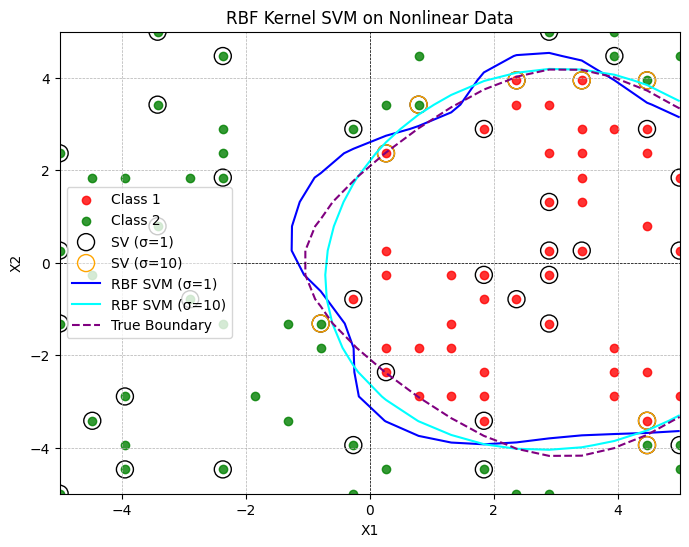

In [124]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# ----------------------------
# Generate non-linear dataset
# ----------------------------
x1 = np.linspace(-5, 5, 20)
x2 = np.linspace(-5, 5, 20)
X1, X2 = np.meshgrid(x1, x2)
points = np.c_[X1.ravel(), X2.ravel()]

def nonlinear_function(x):
    return np.sin(0.5 * x[:, 0]) + np.cos(0.5 * x[:, 1]) - 0.5

Z_nonlinear = nonlinear_function(points).reshape(X1.shape)
points_class1_nl = points[Z_nonlinear.ravel() > 0]
points_class2_nl = points[Z_nonlinear.ravel() < 0]

np.random.seed(42)
num_class1_nl = points_class1_nl.shape[0]
num_class2_nl = points_class2_nl.shape[0]
min_class_size_nl = int(np.ceil(min(num_class1_nl, num_class2_nl) * 0.3))
selected_class1_nl = points_class1_nl[np.random.choice(num_class1_nl, min_class_size_nl, replace=False)]
selected_class2_nl = points_class2_nl[np.random.choice(num_class2_nl, min_class_size_nl, replace=False)]

X_train = np.vstack([selected_class1_nl, selected_class2_nl])
y_train = np.hstack([np.ones(selected_class1_nl.shape[0]), -np.ones(selected_class2_nl.shape[0])])

# ----------------------------
# Define RBF kernel
# ----------------------------
def rbf_kernel(X, sigma=1.0):
    n = X.shape[0]
    K = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            diff = X[i] - X[j]
            K[i, j] = np.exp(-np.dot(diff, diff) / (2 * sigma**2))
    return K

# ----------------------------
# Dual objective for RBF SVM
# ----------------------------
def make_dual_objective_rbf(X, y, sigma=1.0):
    K = rbf_kernel(X, sigma)
    def objective(alpha):
        L = np.sum(alpha) - 0.5 * np.sum(alpha[:, None] * alpha[None, :] * y[:, None] * y[None, :] * K)
        return -L  # minimize -L to maximize
    return objective

# ----------------------------
# Constraints for dual
# ----------------------------
def make_constraints(n, y):
    cons = [{'type': 'ineq', 'fun': (lambda i: (lambda a: a[i]))(i)} for i in range(n)]
    cons.append({'type': 'eq', 'fun': lambda a, y=y: np.sum(a * y)})
    return cons

# ----------------------------
# Optimize dual problem for sigma=1 and sigma=100
# ----------------------------
sigma1 = 1.0
sigma2 = 10.0
x0_dual = np.zeros(X_train.shape[0])
cons_dual = make_constraints(X_train.shape[0], y_train)

# Sigma=1
obj_dual_sigma1 = make_dual_objective_rbf(X_train, y_train, sigma1)
res_dual_sigma1 = minimize(obj_dual_sigma1, x0_dual, constraints=cons_dual)
alpha_sigma1 = res_dual_sigma1.x

# Sigma=100
obj_dual_sigma2 = make_dual_objective_rbf(X_train, y_train, sigma2)
res_dual_sigma2 = minimize(obj_dual_sigma2, x0_dual, constraints=cons_dual)
alpha_sigma2 = res_dual_sigma2.x

# ----------------------------
# RBF decision function
# ----------------------------
def decision_function_rbf(x, X_train, y_train, alpha, sigma=1.0):
    f = np.zeros(x.shape[0])
    for i in range(len(alpha)):
        if alpha[i] > 1e-5:
            diff = x - X_train[i]
            f += alpha[i] * y_train[i] * np.exp(-np.sum(diff**2, axis=1) / (2 * sigma**2))
    return f

# ----------------------------
# Compute bias b for each sigma
# ----------------------------
support_indices_sigma1 = np.where(alpha_sigma1 > 1e-5)[0]
b_sigma1 = np.mean(
    y_train[support_indices_sigma1] -
    decision_function_rbf(X_train[support_indices_sigma1], X_train, y_train, alpha_sigma1, sigma1)
)

support_indices_sigma2 = np.where(alpha_sigma2 > 1e-5)[0]
b_sigma2 = np.mean(
    y_train[support_indices_sigma2] -
    decision_function_rbf(X_train[support_indices_sigma2], X_train, y_train, alpha_sigma2, sigma2)
)

# ----------------------------
# Evaluate decision functions on grid
# ----------------------------
Z_rbf_sigma1 = decision_function_rbf(points, X_train, y_train, alpha_sigma1, sigma1) + b_sigma1
Z_rbf_sigma2 = decision_function_rbf(points, X_train, y_train, alpha_sigma2, sigma2) + b_sigma2
Z_rbf_sigma1 = Z_rbf_sigma1.reshape(X1.shape)
Z_rbf_sigma2 = Z_rbf_sigma2.reshape(X1.shape)

# ----------------------------
# Plot
# ----------------------------
plt.figure(figsize=(8,6))
# RBF boundaries
plt.contour(X1, X2, Z_rbf_sigma1, levels=[0], colors='blue', linestyles='-')
plt.contour(X1, X2, Z_rbf_sigma2, levels=[0], colors='cyan', linestyles='-')
# True nonlinear boundary
Z_nonlinear = nonlinear_function(points).reshape(X1.shape)
plt.contour(X1, X2, Z_nonlinear, levels=[0], colors='purple', linestyles='--')
# Training points
plt.scatter(X_train[y_train==1][:,0], X_train[y_train==1][:,1], color='red', alpha=0.8, label='Class 1')
plt.scatter(X_train[y_train==-1][:,0], X_train[y_train==-1][:,1], color='green', alpha=0.8, label='Class 2')
# Support vectors
plt.scatter(X_train[support_indices_sigma1,0], X_train[support_indices_sigma1,1],
            facecolors='none', edgecolors='black', s=150, label='SV (σ=1)')
plt.scatter(X_train[support_indices_sigma2,0], X_train[support_indices_sigma2,1],
            facecolors='none', edgecolors='orange', s=150, label='SV (σ=10)')

plt.title('RBF Kernel SVM on Nonlinear Data')
plt.xlabel('X1')
plt.ylabel('X2')
plt.axhline(0, color='black', linestyle='--', linewidth=0.5)
plt.axvline(0, color='black', linestyle='--', linewidth=0.5)
plt.grid(True, linestyle='--', linewidth=0.5)
# add legend items for the contours (use proxy artists so contour doesn't warn about 'label')
plt.plot([], [], color='blue', linestyle='-', label='RBF SVM (σ=1)')
plt.plot([], [], color='cyan', linestyle='-', label='RBF SVM (σ=10)')
plt.plot([], [], color='purple', linestyle='--', label='True Boundary')

plt.legend()
plt.show()


## Support Vector Regression (SVR)

SVM can be extended to **regression problems** using the concept of **epsilon-insensitive loss**. Instead of finding a separating hyperplane between classes, SVR fits a function that approximates the target values within a specified tolerance $\varepsilon$.

Following Support Vector Regression Machines H. Drucker, C. J. C. Burges, L. Kaufman, A. J. Smola, V. Vapnik, Advances in Neural Information Processing Systems (NIPS), 1996.  https://proceedings.neurips.cc/paper_files/paper/1996/file/d38901788c533e8286cb6400b40b386d-Paper.pdf

### Objective

Given training data $(x_i, y_i)$, SVR solves:

$$
\min_{w, b, \xi_i, \xi_i^*} \frac{1}{2} \|w\|^2 + C \sum_{i=1}^n (\xi_i + \xi_i^*)
$$

subject to:

$$
\begin{aligned}
y_i - (w^\top x_i + b) &\le \varepsilon + \xi_i \\
(w^\top x_i + b) - y_i &\le \varepsilon + \xi_i^* \\
\xi_i, \xi_i^* &\ge 0
\end{aligned}
$$

- $\varepsilon$ defines a **margin of tolerance**: deviations smaller than $\varepsilon$ are ignored.  
- $\xi_i, \xi_i^*$ are **slack variables** for points outside the $\varepsilon$-tube.  
- $C$ controls the trade-off between flatness (small $\|w\|^2$) and tolerance to errors.  

### Dual Formulation

Introducing Lagrange multipliers $\alpha_i, \alpha_i^*$ leads to the dual problem:

$$
\max_{\alpha, \alpha^*} -\frac{1}{2} \sum_{i,j} (\alpha_i - \alpha_i^*)(\alpha_j - \alpha_j^*) x_i^\top x_j - \varepsilon \sum_i (\alpha_i + \alpha_i^*) + \sum_i y_i (\alpha_i - \alpha_i^*)
$$

subject to:

$$
\sum_i (\alpha_i - \alpha_i^*) = 0, \quad 0 \le \alpha_i, \alpha_i^* \le C
$$

The **regression function** is:

$$
f(x) = \sum_i (\alpha_i - \alpha_i^*) K(x_i, x) + b
$$

- $K(x_i, x)$ can be a **linear kernel**, **polynomial kernel**, or **RBF kernel**, just like in classification.  
- Only points with nonzero $(\alpha_i - \alpha_i^*)$ (the **support vectors**) contribute to the prediction.  

### Intuition

- SVR tries to **fit a function within a tube of width $\varepsilon$**.  
- Points inside the tube do not contribute to the loss; only points outside influence the solution.  
- Using kernels allows **nonlinear regression** in high-dimensional spaces.  

### Advantages

- Can handle **high-dimensional data** using kernels.  
- Robust to outliers (controlled via $C$ and $\varepsilon$).  
- Provides **sparse solutions**, since only support vectors determine the model.

### Epsilon-Insensitive Loss in SVR

Support Vector Regression (SVR) uses the **epsilon-insensitive loss** to tolerate small deviations between predictions and true values. For a training point $(x_i, y_i)$ with prediction $f(x_i)$, the loss is:

$$
L_\varepsilon(y_i, f(x_i)) = \max\big(0, |y_i - f(x_i)| - \varepsilon \big)
$$

- Predictions within $\varepsilon$ of the true value incur **zero loss**.  
- Only points outside the $\varepsilon$-tube contribute to the loss and become **support vectors**.  
- The parameter $\varepsilon$ controls model sparsity and robustness: larger $\varepsilon$ produces fewer support vectors and smoother regression; smaller $\varepsilon$ fits the data more tightly.  

The parameter $\varepsilon$ also influences the **bias–variance tradeoff** in SVR:  

- **Larger $\varepsilon$** → wider epsilon-tube, fewer support vectors, smoother regression. This increases **bias** but reduces **variance**.  
- **Smaller $\varepsilon$** → narrower epsilon-tube, more support vectors, tighter fit to the data. This decreases **bias** but increases **variance**.  

Adjusting $\varepsilon$ allows control over model flexibility and the tradeoff between underfitting and overfitting.


This mechanism is analogous to the margin in SVM classification: **points inside the tube are ignored**, while only the extreme deviations influence the regression function.



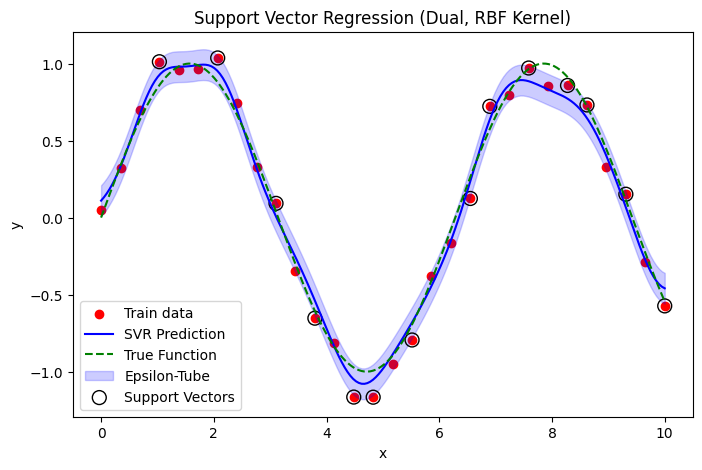

In [132]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# ----------------------------
# 1D Training data
# ----------------------------
np.random.seed(42)
X = np.linspace(0, 10, 30).reshape(-1, 1)
y = np.sin(X).ravel() + 0.1*np.random.randn(X.shape[0])

# ----------------------------
# RBF Kernel
# ----------------------------
def rbf_kernel(X, sigma=0.5):
    n = X.shape[0]
    K = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            diff = X[i] - X[j]
            K[i, j] = np.exp(-np.dot(diff, diff) / (2*sigma**2))
    return K

# ----------------------------
# Dual Objective SVR
# ----------------------------
def make_dual_objective_svr(X, y, epsilon=0.1,sigma=0.5):
    K = rbf_kernel(X, sigma)
    n = X.shape[0]
    def objective(alpha_all):
        # alpha_all contains alpha_i and alpha_i* concatenated
        alpha = alpha_all[:n]
        alpha_star = alpha_all[n:]
        diff = alpha - alpha_star
        L = -0.5 * np.sum(np.outer(diff, diff) * K) - epsilon * np.sum(alpha + alpha_star) + np.sum(diff * y)
        return -L
    return objective

# ----------------------------
# Constraints
# ----------------------------
def make_constraints_svr(n, C):
    cons = []
    # 0 <= alpha_i <= C, 0 <= alpha_i* <= C
    for i in range(2*n):
        cons.append({'type': 'ineq', 'fun': (lambda i: (lambda a: C - a[i]))(i)})  # alpha <= C
        cons.append({'type': 'ineq', 'fun': (lambda i: (lambda a: a[i]))(i)})      # alpha >= 0
    return cons

# ----------------------------
# Optimize dual
# ----------------------------
n = X.shape[0]
x0 = np.zeros(2*n)  # alpha_i and alpha_i*
obj_dual = make_dual_objective_svr(X, y, epsilon=0.1, sigma=0.5)
cons_dual = make_constraints_svr(n, C=10)
res = minimize(obj_dual, x0, constraints=cons_dual)
alpha_all = res.x
alpha = alpha_all[:n]
alpha_star = alpha_all[n:]
diff_alpha = alpha - alpha_star


# ----------------------------
# Compute bias b using support vectors
# ----------------------------
support_indices = np.where(np.abs(diff_alpha) > 1e-5)[0]
K_full = rbf_kernel(X, sigma=0.5)  # Kernel of all training points
support_K = K_full[support_indices, :]  # Kernel between support vectors and all points
b = np.mean(y[support_indices] - np.dot(diff_alpha, support_K.T)) # Simplified bias calculation using the mean over support vectors. In practice, you might want to use a more robust method to compute b, especially if there are many support vectors.

# ----------------------------
# Decision function (vectorized)
# ----------------------------
def svr_predict(X_test, X_train, diff_alpha, b, sigma=0.5):
    # Compute pairwise squared distances
    sq_dists = np.sum((X_test[:, None, :] - X_train[None, :, :])**2, axis=2)
    K_test = np.exp(-sq_dists / (2*sigma**2))
    y_pred = np.dot(K_test, diff_alpha) + b
    return y_pred


# ----------------------------
# Prediction and visualization
# ----------------------------
X_test = np.linspace(0, 10, 200).reshape(-1, 1)
y_pred = svr_predict(X_test, X, diff_alpha, b, sigma=0.5)

plt.figure(figsize=(8,5))
plt.scatter(X, y, color='red', label='Train data')
plt.plot(X_test, y_pred, color='blue', label='SVR Prediction')
plt.plot(X_test, np.sin(X_test).ravel(), color='green', linestyle='--', label='True Function')
plt.fill_between(X_test.ravel(), y_pred - 0.1, y_pred + 0.1, color='blue', alpha=0.2, label='Epsilon-Tube')
plt.scatter(X[support_indices], y[support_indices], s=100, facecolors='none', edgecolors='black', label='Support Vectors')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Support Vector Regression (Dual, RBF Kernel)')
plt.legend()
plt.show()
